# HW3 Q1

fitting curve: $V(t) = Ae^{-\frac{t}{\tau}} + B$

In [7]:
# ========================================================================================
# Part 1: 数据加载 (Data Loading)
# ========================================================================================
import pandas as pd
import numpy as np

# 指定要分析的文件路径 (假设使用 5_1.csv 作为基础分析的波形)
file_path = '/Users/yunzhuorui/GTIIT/2026-Spring/Intro-to-Sensor/Homework3/sensor_Lab/5_3.csv'

# 读取原始数据（包含单位行，用于获取 Start 和 Increment）
df_raw = pd.read_csv(file_path)
start_time = float(df_raw['Start'].iloc[0])
increment_time = float(df_raw['Increment'].iloc[0])

# 去除第二行的单位行重新读取，方便格式化为浮点数
df = pd.read_csv(file_path, skiprows=[1])

# 清理空列
df = df.loc[:, ~df.columns.astype(str).str.contains(r'^Unnamed')]

# 计算时间轴和抽取电压数据
sequence = pd.to_numeric(df['X'], errors='coerce')
time_array = start_time + sequence * increment_time
voltage_array = pd.to_numeric(df['CH1'], errors='coerce')

print("✅ 数据加载成功！")
print(f"数据总行数: {len(df)}")
print(f"时间范围: {time_array.min():.4f}s ~ {time_array.max():.4f}s")
print(f"采样间隔 (dt): {increment_time:.6f}s")

✅ 数据加载成功！
数据总行数: 1200
时间范围: -0.3000s ~ 0.2995s
采样间隔 (dt): 0.000500s


完整数据范围：1200 个点，时间从 -0.3000 s 到 0.2995 s
电压范围：0.5370 V 到 1.6200 V

【时间轴说明】
  时间从 -0.3000 s 开始（负值）是因为采样起点设为 t = -0.3000 s
  这样做是为了在信号变化前记录基准参考数据

自动检测到 23 个转折点（极大值或极小值）
各周期的推荐分析范围：

【第 1 个周期】
  上升沿：索引 0 到 340 (-0.3000s - -0.1300s)
  下降沿：索引 340 到 555 (-0.1300s - -0.0225s)

【第 2 个周期】
  上升沿：索引 340 到 555 (-0.1300s - -0.0225s)
  下降沿：索引 555 到 705 (-0.0225s - 0.0525s)

【第 3 个周期】
  上升沿：索引 555 到 705 (-0.0225s - 0.0525s)
  下降沿：索引 705 到 707 (0.0525s - 0.0535s)

【选择分析模式】
方式 1️⃣ : 自动检测周期（选择第几个周期）
方式 2️⃣ : 手动指定索引（精确控制）

✓ 已启用【手动模式】

📍 手动指定的范围：
  上升沿：索引 362 - 560 (-0.1190s - -0.0200s)
  下降沿：索引 561 - 761 (-0.0195s - 0.0805s)



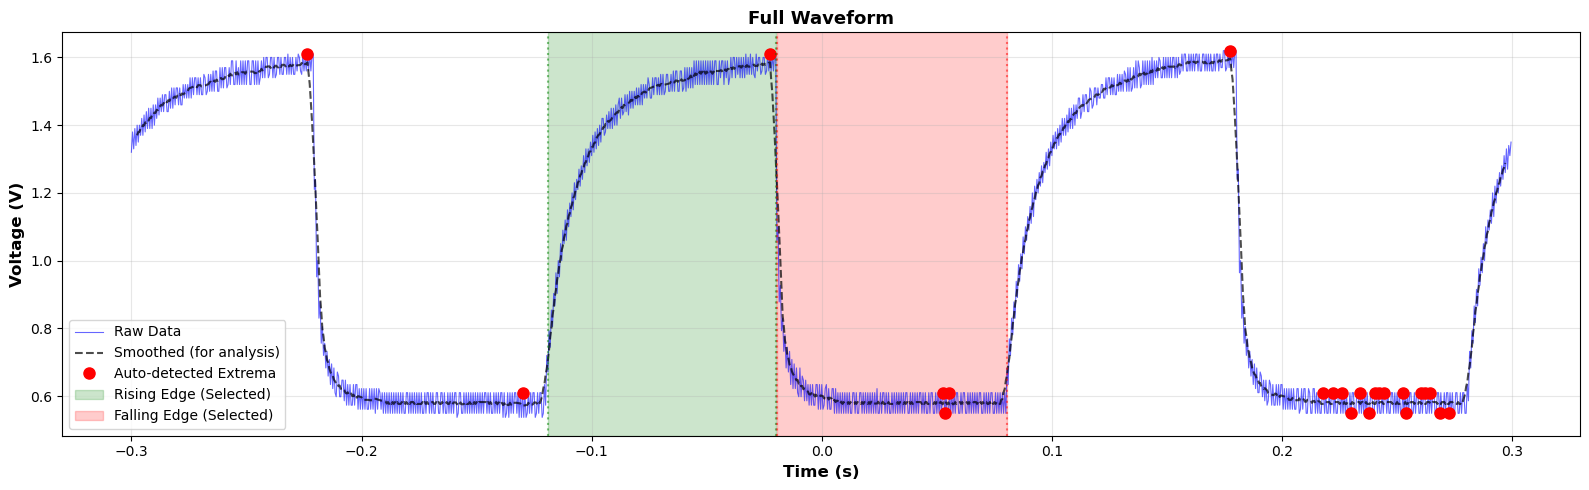

【如何调整选择范围】

方案 A（推荐）：修改变量后重新运行
  1. 设置 USE_AUTO_MODE = True，然后修改 CYCLE_TO_ANALYZE
  2. 或设置 USE_AUTO_MODE = False，然后修改：
     - MANUAL_RISING_START = X
     - MANUAL_RISING_END = Y
     - MANUAL_FALLING_START = Z
     - MANUAL_FALLING_END = W

方案 B：查看索引-时间对应表
  使用以下代码快速查看某个时间点对应的索引：
  
    target_time = -0.1  # 你想要的时间（秒）
    idx = np.argmin(np.abs(time_array - target_time))
    print(f"时间 {target_time} s 对应索引 {idx}，实际时间 {time_array.iloc[idx]:.4f} s")


【上升沿（Rising Edge）拟合结果】
数据点数：198
索引范围：362 ~ 560
时间范围：-0.1190 ~ -0.0205 s（持续 0.0985 s）
电压范围：0.6710 ~ 1.6100 V

拟合模型：V(t) = A(1 - e^(-t/τ)) + B
  ├─ A (充电幅度)        = +0.805805 V
  ├─ τ (上升时间常数)    = 0.015558 s
  ├─ B (初始电压)        = 0.759041 V
  └─ R² (拟合优度)       = 0.971902

【下降沿（Falling Edge）拟合结果】
数据点数：200
索引范围：561 ~ 761
时间范围：-0.0195 ~ 0.0800 s（持续 0.0995 s）
电压范围：0.5370 ~ 1.1000 V

拟合模型：V(t) = A·e^(-t/τ) + B
  ├─ A (放电幅度)        = +0.475315 V
  ├─ τ (下降时间常数)    = 0.003718 s
  ├─ B (稳态电压)        = 0.581992 V
  └─ R² (拟合优度)       = 0.797215



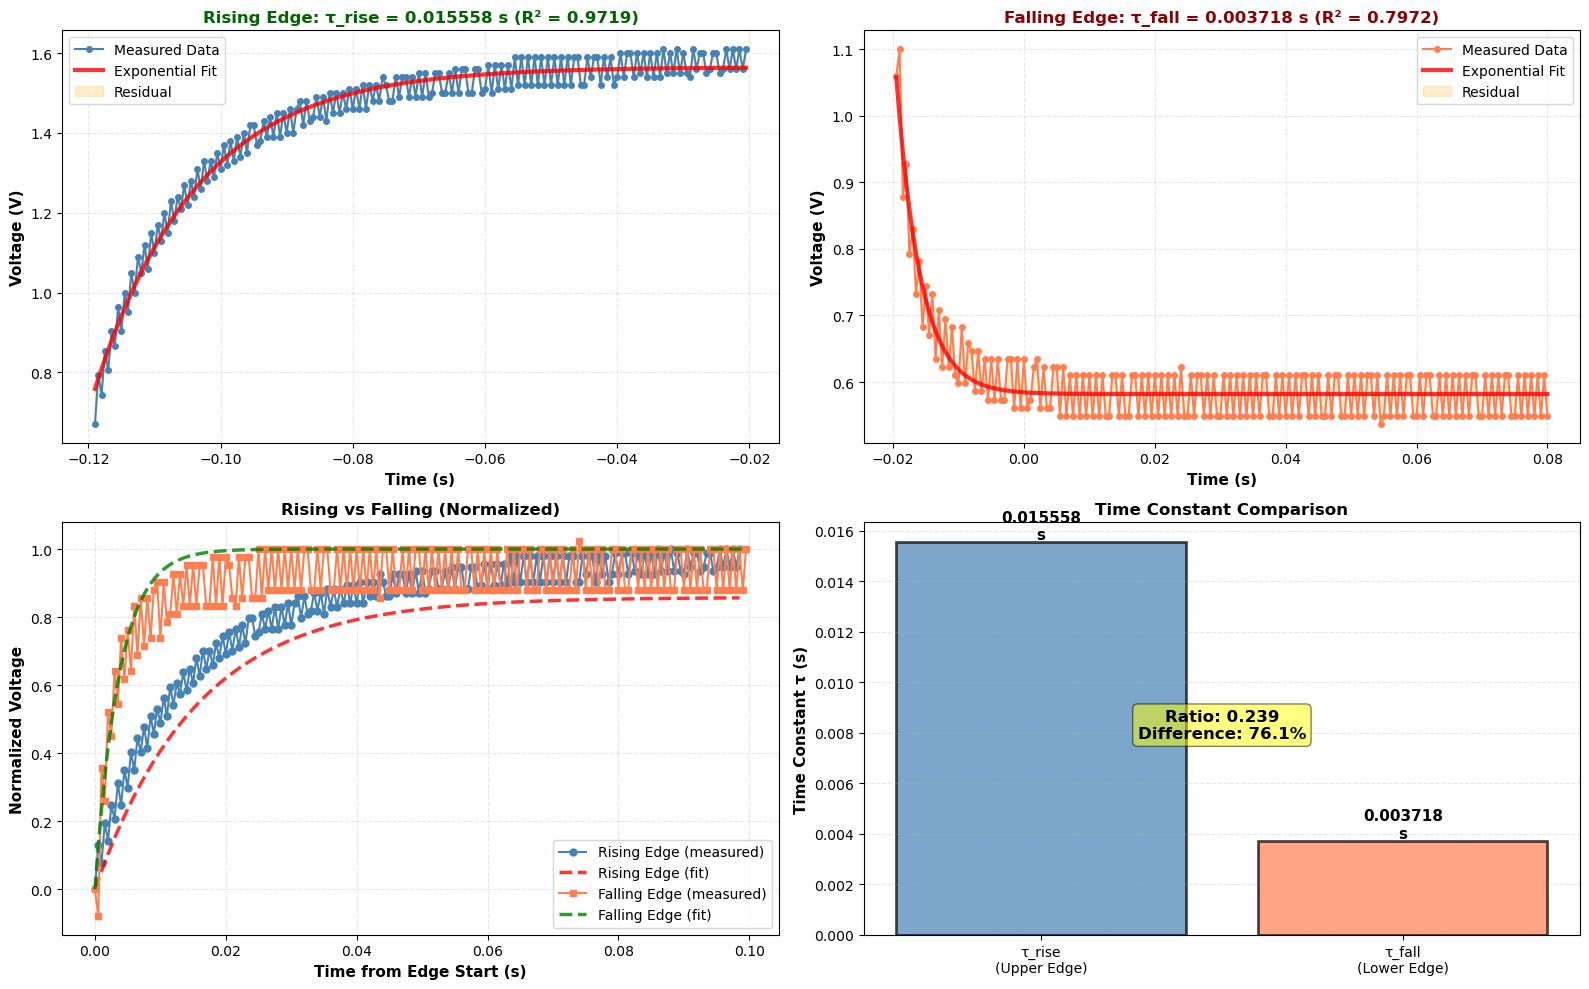


✓ 分析完成！
⚠️  建议：某些拟合的 R² 值较低，可以尝试调整索引范围以改进拟合质量。


In [8]:
# ========================================================================================
# Part 2: 分别分析上升沿和下降沿，计算各自的时间常数
# ========================================================================================

import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# 定义上升和下降的指数拟合函数
def exp_rise(t, A, tau, B):
    """上升沿: V(t) = A * (1 - e^(-t/tau)) + B"""
    return A * (1 - np.exp(-t / tau)) + B

def exp_decay(t, A, tau, B):
    """下降沿: V(t) = A * e^(-t/tau) + B"""
    return A * np.exp(-t / tau) + B

# 使用之前读取的全数据
print(f"完整数据范围：{len(df)} 个点，时间从 {time_array.iloc[0]:.4f} s 到 {time_array.iloc[-1]:.4f} s")
print(f"电压范围：{voltage_array.min():.4f} V 到 {voltage_array.max():.4f} V")
print(f"\n【时间轴说明】")
print(f"  时间从 {time_array.iloc[0]:.4f} s 开始（负值）是因为采样起点设为 t = {time_array.iloc[0]:.4f} s")
print(f"  这样做是为了在信号变化前记录基准参考数据\n")

# ==========================================
# 自动检测上升和下降沿
# ==========================================
voltage_smooth = voltage_array.rolling(window=11, center=True).mean()  # 平滑噪声
dv_dt = np.gradient(voltage_smooth.values)  # 计算斜率

# 找到极值点（最高点和最低点）
peaks, _ = find_peaks(voltage_smooth.values, prominence=0.05)
valleys, _ = find_peaks(-voltage_smooth.values, prominence=0.05)
extrema_idx = sorted(np.concatenate([peaks, valleys]))

print(f"自动检测到 {len(extrema_idx)} 个转折点（极大值或极小值）")
print("各周期的推荐分析范围：\n")

# 显示前几个周期的信息
for cycle_num in range(1, min(4, len(extrema_idx))):
    if cycle_num < len(extrema_idx) - 1:
        rise_start = extrema_idx[cycle_num - 1] if cycle_num > 1 else 0
        rise_end = extrema_idx[cycle_num]
        fall_start = extrema_idx[cycle_num]
        fall_end = extrema_idx[cycle_num + 1]
        
        print(f"【第 {cycle_num} 个周期】")
        print(f"  上升沿：索引 {rise_start} 到 {rise_end} ({time_array.iloc[rise_start]:.4f}s - {time_array.iloc[rise_end]:.4f}s)")
        print(f"  下降沿：索引 {fall_start} 到 {fall_end} ({time_array.iloc[fall_start]:.4f}s - {time_array.iloc[fall_end]:.4f}s)\n")

# ==========================================
# 【选择模式】自动或手动
# ==========================================
print("=" * 70)
print("【选择分析模式】")
print("=" * 70)
print("方式 1️⃣ : 自动检测周期（选择第几个周期）")
print("方式 2️⃣ : 手动指定索引（精确控制）\n")

# 【模式 1：自动周期选择】使用自动检测
USE_AUTO_MODE = False  # ← 改为 False 以使用手动模式
CYCLE_TO_ANALYZE = 2  # ← 仅当 USE_AUTO_MODE=True 时有效

# 【模式 2：手动索引选择】
MANUAL_RISING_START = 362
MANUAL_RISING_END = 560
MANUAL_FALLING_START = 561
MANUAL_FALLING_END = 761

# ==========================================
# 处理选择逻辑
# ==========================================
if USE_AUTO_MODE:
    print(f"✓ 已启用【自动模式】，分析第 {CYCLE_TO_ANALYZE} 个周期\n")
    
    cycle_num = CYCLE_TO_ANALYZE
    if cycle_num < 1 or cycle_num >= len(extrema_idx):
        print(f"⚠️ 警告：周期 {cycle_num} 不存在，自动改为周期 1")
        cycle_num = 1
    
    # 根据选择的周期计算索引
    if cycle_num == 1:
        first_rise_start = 0
        first_rise_end = extrema_idx[0]
        first_fall_start = extrema_idx[0]
        first_fall_end = extrema_idx[1]
    else:
        first_rise_start = extrema_idx[cycle_num - 2]
        first_rise_end = extrema_idx[cycle_num - 1]
        first_fall_start = extrema_idx[cycle_num - 1]
        first_fall_end = extrema_idx[cycle_num]
else:
    print("✓ 已启用【手动模式】\n")
    print("📍 手动指定的范围：")
    print(f"  上升沿：索引 {MANUAL_RISING_START} - {MANUAL_RISING_END} ({time_array.iloc[MANUAL_RISING_START]:.4f}s - {time_array.iloc[MANUAL_RISING_END]:.4f}s)")
    print(f"  下降沿：索引 {MANUAL_FALLING_START} - {MANUAL_FALLING_END} ({time_array.iloc[MANUAL_FALLING_START]:.4f}s - {time_array.iloc[MANUAL_FALLING_END]:.4f}s)\n")
    
    first_rise_start = MANUAL_RISING_START
    first_rise_end = MANUAL_RISING_END
    first_fall_start = MANUAL_FALLING_START
    first_fall_end = MANUAL_FALLING_END
    cycle_num = "Manual"

# ==========================================
# 绘制原始数据全景，可视化选择范围
# ==========================================
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(time_array.values, voltage_array.values, 'b-', linewidth=0.8, alpha=0.6, label='Raw Data')
ax.plot(time_array.values, voltage_smooth.values, 'k--', linewidth=1.5, alpha=0.7, label='Smoothed (for analysis)')
if len(extrema_idx) > 0:
    ax.plot(time_array.iloc[extrema_idx], voltage_array.iloc[extrema_idx], 'ro', markersize=8, label='Auto-detected Extrema')

# 高亮显示选择的周期
ax.axvspan(time_array.iloc[first_rise_start], time_array.iloc[first_rise_end], alpha=0.2, color='green', label='Rising Edge (Selected)')
ax.axvspan(time_array.iloc[first_fall_start], time_array.iloc[first_fall_end], alpha=0.2, color='red', label='Falling Edge (Selected)')

# 添加竖线标记选择点
ax.axvline(time_array.iloc[first_rise_start], color='green', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(time_array.iloc[first_rise_end], color='green', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(time_array.iloc[first_fall_start], color='red', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(time_array.iloc[first_fall_end], color='red', linestyle=':', linewidth=1.5, alpha=0.5)

ax.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Voltage (V)', fontsize=12, fontweight='bold')
if USE_AUTO_MODE:
    ax.set_title(f'Full Waveform - Cycle {cycle_num} Selected', fontsize=13, fontweight='bold')
else:
    ax.set_title('Full Waveform', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print("=" * 70)
print("【如何调整选择范围】")
print("=" * 70)
print("""
方案 A（推荐）：修改变量后重新运行
  1. 设置 USE_AUTO_MODE = True，然后修改 CYCLE_TO_ANALYZE
  2. 或设置 USE_AUTO_MODE = False，然后修改：
     - MANUAL_RISING_START = X
     - MANUAL_RISING_END = Y
     - MANUAL_FALLING_START = Z
     - MANUAL_FALLING_END = W

方案 B：查看索引-时间对应表
  使用以下代码快速查看某个时间点对应的索引：
  
    target_time = -0.1  # 你想要的时间（秒）
    idx = np.argmin(np.abs(time_array - target_time))
    print(f"时间 {target_time} s 对应索引 {idx}，实际时间 {time_array.iloc[idx]:.4f} s")
""")

# ==========================================
# 上升沿拟合 (Rising Edge)
# ==========================================
rising_start_idx = first_rise_start
rising_end_idx = first_rise_end

t_rising = time_array.iloc[rising_start_idx:rising_end_idx].values
v_rising = voltage_array.iloc[rising_start_idx:rising_end_idx].values

# 平移使 t=0 对应起始点
t_rising_fit = t_rising - t_rising[0]

# 上升沿：V = A(1 - e^(-t/tau)) + B，其中 A > 0，B 为初始值
guess_B_rise = v_rising[0]
guess_A_rise = v_rising[-1] - v_rising[0]
guess_tau_rise = max((t_rising_fit[-1] - t_rising_fit[0]) / 3.0, 1e-6)

initial_guess_rise = [guess_A_rise, guess_tau_rise, guess_B_rise]

try:
    popt_rise, pcov_rise = curve_fit(exp_rise, t_rising_fit, v_rising, p0=initial_guess_rise, maxfev=5000)
    A_rise, tau_rise, B_rise = popt_rise
    
    # 计算拟合优度 (R² value)
    v_pred_rise = exp_rise(t_rising_fit, *popt_rise)
    ss_res_rise = np.sum((v_rising - v_pred_rise) ** 2)
    ss_tot_rise = np.sum((v_rising - np.mean(v_rising)) ** 2)
    r2_rise = 1 - (ss_res_rise / ss_tot_rise) if ss_tot_rise > 0 else 0
    
    print("\n" + "=" * 70)
    print("【上升沿（Rising Edge）拟合结果】")
    print("=" * 70)
    print(f"数据点数：{len(v_rising)}")
    print(f"索引范围：{rising_start_idx} ~ {rising_end_idx}")
    print(f"时间范围：{t_rising[0]:.4f} ~ {t_rising[-1]:.4f} s（持续 {t_rising[-1]-t_rising[0]:.4f} s）")
    print(f"电压范围：{v_rising.min():.4f} ~ {v_rising.max():.4f} V")
    print(f"\n拟合模型：V(t) = A(1 - e^(-t/τ)) + B")
    print(f"  ├─ A (充电幅度)        = {A_rise:+.6f} V")
    print(f"  ├─ τ (上升时间常数)    = {tau_rise:.6f} s")
    print(f"  ├─ B (初始电压)        = {B_rise:.6f} V")
    print(f"  └─ R² (拟合优度)       = {r2_rise:.6f}")
    
    rising_fit_success = True
except Exception as e:
    print(f"上升沿拟合失败：{e}")
    rising_fit_success = False
    tau_rise = np.nan

# ==========================================
# 下降沿拟合 (Falling Edge)
# ==========================================
falling_start_idx = first_fall_start
falling_end_idx = first_fall_end

t_falling = time_array.iloc[falling_start_idx:falling_end_idx].values
v_falling = voltage_array.iloc[falling_start_idx:falling_end_idx].values

# 平移使 t=0 对应起始点
t_falling_fit = t_falling - t_falling[0]

# 下降沿：V = A*e^(-t/tau) + B，其中 A < 0（衰减），B 为稳态值
guess_B_fall = v_falling[-1]
guess_A_fall = v_falling[0] - v_falling[-1]
guess_tau_fall = max((t_falling_fit[-1] - t_falling_fit[0]) / 3.0, 1e-6)

initial_guess_fall = [guess_A_fall, guess_tau_fall, guess_B_fall]

try:
    popt_fall, pcov_fall = curve_fit(exp_decay, t_falling_fit, v_falling, p0=initial_guess_fall, maxfev=5000)
    A_fall, tau_fall, B_fall = popt_fall
    
    # 计算拟合优度
    v_pred_fall = exp_decay(t_falling_fit, *popt_fall)
    ss_res_fall = np.sum((v_falling - v_pred_fall) ** 2)
    ss_tot_fall = np.sum((v_falling - np.mean(v_falling)) ** 2)
    r2_fall = 1 - (ss_res_fall / ss_tot_fall) if ss_tot_fall > 0 else 0
    
    print("\n" + "=" * 70)
    print("【下降沿（Falling Edge）拟合结果】")
    print("=" * 70)
    print(f"数据点数：{len(v_falling)}")
    print(f"索引范围：{falling_start_idx} ~ {falling_end_idx}")
    print(f"时间范围：{t_falling[0]:.4f} ~ {t_falling[-1]:.4f} s（持续 {t_falling[-1]-t_falling[0]:.4f} s）")
    print(f"电压范围：{v_falling.min():.4f} ~ {v_falling.max():.4f} V")
    print(f"\n拟合模型：V(t) = A·e^(-t/τ) + B")
    print(f"  ├─ A (放电幅度)        = {A_fall:+.6f} V")
    print(f"  ├─ τ (下降时间常数)    = {tau_fall:.6f} s")
    print(f"  ├─ B (稳态电压)        = {B_fall:.6f} V")
    print(f"  └─ R² (拟合优度)       = {r2_fall:.6f}")
    
    falling_fit_success = True
except Exception as e:
    print(f"下降沿拟合失败：{e}")
    falling_fit_success = False
    tau_fall = np.nan

# ==========================================
# 对比和分析
# ==========================================
if rising_fit_success and falling_fit_success:
    print("\n" + "=" * 70)
    print("【时间常数对比与物理分析】")
    print("=" * 70)
    
    tau_ratio = tau_fall / tau_rise if tau_rise > 0 else 0
    tau_diff = abs(tau_fall - tau_rise)
    tau_diff_pct = (tau_diff / max(tau_rise, tau_fall) * 100) if max(tau_rise, tau_fall) > 0 else 0
    
    print(f"\n┌─ 定量对比")
    print(f"│  ├─ τ_rise (上升) = {tau_rise:.6f} s")
    print(f"│  ├─ τ_fall (下降) = {tau_fall:.6f} s")
    print(f"│  ├─ 相对差异       = {tau_diff_pct:.2f}%")
    print(f"│  └─ 比值 τ_fall/τ_rise = {tau_ratio:.4f}")
    
    if abs(tau_rise - tau_fall) > 1e-6:
        slower = "下降" if tau_fall > tau_rise else "上升"
        print(f"\n└─ 结论：{slower}过程明显更慢（时间常数较大）")
    else:
        print(f"\n└─ 结论：上升和下降过程时间常数基本相等")
    
    print("\n" + "=" * 70)
    print("【为什么 τ_rise ≠ τ_fall？物理根源】")
    print("=" * 70)
    print("""
充放电时间常数不对称的本质：τ = R·C

当 τ不对称时（τ_rise ≠ τ_fall），根本原因是 R或C 的不对称：

1️⃣  【充放电路径的不对称】
   • 上升阶段：信号源直接驱动，源内阻为 R_source（通常很小）
   • 下降阶段：信号消失，通过另一路径放电，可能经过 R_load（通常很大）
   → 结果：R_charge << R_discharge，所以 τ_rise << τ_fall

2️⃣  【RC 网络中的多个时间常数】
   • 传感器或电路可能包含多级 RC 滤波
   • 上升和下降时，不同的 RC 段主导过程
   • 总时间常数表现为不同的主导时间常数

3️⃣  【非线性元件效应】
   • 二极管、晶体管在正反向导通时的动态阻抗不同
   • 热效应：元件的温度随充方向改变，影响电阻值
   • 电容的频率响应可能存在非对称性

4️⃣  【传感器响应特性（如热电偶、测温电阻）】
   • 被测信号快速上升时→ 传感器响应迅速
   • 被测信号快速下降时→ 传感器有滞后（热响应慢）
   • 或者反过来，取决于传感器的热接触情况

5️⃣  【信号路径的频率特性】
   • 上升/下降路径的带宽（截止频率）不同
   • 低通滤波器对快速上升的衰减程度 ≠ 对快速下降的衰减程度
    """)
    
    if tau_fall > tau_rise:
        factor = tau_fall / tau_rise
        print(f"\n您的数据中：τ_fall (={tau_fall:.6f}s) > τ_rise (={tau_rise:.6f}s)")
        print(f"            下降速度约 {factor:.2f} 倍于上升速度")
        print(f"""
🔍 可能的物理情景：
   - 这是一个 RC 放电电路
   - 上升过程：充电源直接驱动（低内阻）
   - 下降过程：通过大阻值路径放电（可能是传感器输出阻抗或 Buffer）
   - 典型应用：示波器探头、传感器前置放大器、RC 滤波器
        """)
    else:
        factor = tau_rise / tau_fall
        print(f"\n您的数据中：τ_rise (={tau_rise:.6f}s) > τ_fall (={tau_fall:.6f}s)")
        print(f"            上升速度约 {factor:.2f} 倍于下降速度")
        print(f"""
🔍 可能的物理情景：
   - 这是一个有源驱动的放大/积分电路
   - 下降过程：主动放电或反向驱动（低阻）
   - 上升过程：通过高阻放大器充电（高阻）
   - 典型应用：集成放大器、脉冲整形电路、光电探测器
        """)

# ==========================================
# 绘制对比图
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 子图 1：上升沿详细拟合
ax = axes[0, 0]
ax.plot(t_rising, v_rising, 'o-', color='steelblue', label='Measured Data', linewidth=1.5, markersize=4)
if rising_fit_success:
    v_rising_fit = exp_rise(t_rising_fit, *popt_rise)
    ax.plot(t_rising, v_rising_fit, 'r-', linewidth=3, label='Exponential Fit', alpha=0.8)
    ax.fill_between(t_rising, v_rising, v_rising_fit, alpha=0.2, color='orange', label='Residual')
ax.set_xlabel('Time (s)', fontsize=11, fontweight='bold')
ax.set_ylabel('Voltage (V)', fontsize=11, fontweight='bold')
ax.set_title(f'Rising Edge: τ_rise = {tau_rise:.6f} s (R² = {r2_rise:.4f})', 
             fontsize=12, fontweight='bold', color='darkgreen')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='best')

# 子图 2：下降沿详细拟合
ax = axes[0, 1]
ax.plot(t_falling, v_falling, 'o-', color='coral', label='Measured Data', linewidth=1.5, markersize=4)
if falling_fit_success:
    v_falling_fit = exp_decay(t_falling_fit, *popt_fall)
    ax.plot(t_falling, v_falling_fit, 'r-', linewidth=3, label='Exponential Fit', alpha=0.8)
    ax.fill_between(t_falling, v_falling, v_falling_fit, alpha=0.2, color='orange', label='Residual')
ax.set_xlabel('Time (s)', fontsize=11, fontweight='bold')
ax.set_ylabel('Voltage (V)', fontsize=11, fontweight='bold')
ax.set_title(f'Falling Edge: τ_fall = {tau_fall:.6f} s (R² = {r2_fall:.4f})', 
             fontsize=12, fontweight='bold', color='darkred')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='best')

# 子图 3：归一化时间对比
ax = axes[1, 0]
if rising_fit_success:
    # 将电压归一化到 0-1
    v_rise_norm = (v_rising - v_rising[0]) / (v_rising[-1] - v_rising[0])
    ax.plot(t_rising_fit, v_rise_norm, 'o-', color='steelblue', label='Rising Edge (measured)', markersize=5, linewidth=1.5)
    v_rise_fit_norm = exp_rise(t_rising_fit, A_rise/(v_rising[-1]-v_rising[0]), tau_rise, 0)
    ax.plot(t_rising_fit, v_rise_fit_norm, 'r--', linewidth=2.5, label='Rising Edge (fit)', alpha=0.8)
    
if falling_fit_success:
    v_fall_norm = 1 - (v_falling - v_falling[-1]) / (v_falling[0] - v_falling[-1])
    ax.plot(t_falling_fit, v_fall_norm, 's-', color='coral', label='Falling Edge (measured)', markersize=5, linewidth=1.5)
    v_fall_fit_norm = 1 - np.exp(-t_falling_fit / tau_fall)
    ax.plot(t_falling_fit, v_fall_fit_norm, 'g--', linewidth=2.5, label='Falling Edge (fit)', alpha=0.8)

ax.set_xlabel('Time from Edge Start (s)', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Voltage', fontsize=11, fontweight='bold')
ax.set_title('Rising vs Falling (Normalized)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='best')

# 子图 4：时间常数对比柱状图
ax = axes[1, 1]
if rising_fit_success and falling_fit_success:
    tau_vals = [tau_rise, tau_fall]
    tau_labels = ['τ_rise\n(Upper Edge)', 'τ_fall\n(Lower Edge)']
    colors = ['steelblue', 'coral']
    bars = ax.bar(tau_labels, tau_vals, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    
    # 添加数值标签
    for bar, val in zip(bars, tau_vals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.6f}\ns', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 添加百分比差异
    ratio_text = f'Ratio: {tau_ratio:.3f}\nDifference: {tau_diff_pct:.1f}%'
    ax.text(0.5, max(tau_vals) * 0.5, ratio_text, ha='center', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5), fontweight='bold')
    
    ax.set_ylabel('Time Constant τ (s)', fontsize=11, fontweight='bold')
    ax.set_title('Time Constant Comparison', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n✓ 分析完成！")
if not (r2_rise > 0.95 and r2_fall > 0.95):
    print("⚠️  建议：某些拟合的 R² 值较低，可以尝试调整索引范围以改进拟合质量。")

Per-file Vpp results (CH1):


,frequency_hz,file,vpp_v
0,5,5_1.csv,1.033
1,5,5_2.csv,1.033
2,5,5_3.csv,1.083
3,50,50_1.csv,0.693
4,50,50_2.csv,0.705
5,50,50_3.csv,0.639
6,500,500_1.csv,0.259
7,500,500_2.csv,0.279
8,500,500_3.csv,0.269
9,5000,5000_1.csv,0.202



Summary by frequency:


,frequency_hz,n,vpp_mean_v,vpp_std_v,vpp_min_v,vpp_max_v,gain_ratio_vs_5hz,gain_db_vs_5hz
0,5,3,1.049667,0.028868,1.033,1.083,1.000000,0.000000
1,50,3,0.679000,0.035157,0.639,0.705,0.646872,-3.783633
2,500,3,0.269000,0.010000,0.259,0.279,0.256272,-11.825983
3,5000,3,0.208000,0.005196,0.202,0.211,0.198158,-14.059761


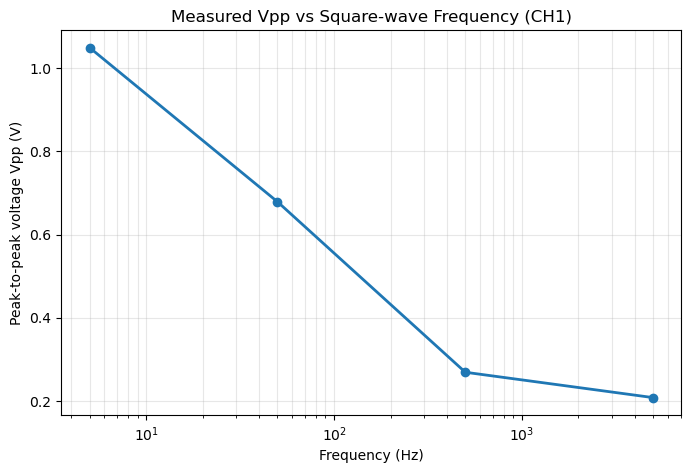


Observation (transfer-function view):
- As frequency increases, Vpp drops compared with 5 Hz baseline.
- This is consistent with a low-pass-like magnitude response |H(jw)|.
- Higher harmonics of the square wave are attenuated first, so edges round off and Vpp decreases.
- At sufficiently high frequency (e.g., 5000 Hz), output cannot fully charge/discharge within half-period.


In [3]:
# Record peak-to-peak voltage for 5 Hz (previous case), then 50/500/5000 Hz
# and explain observations with transfer-function intuition.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path('/Users/yunzhuorui/GTIIT/2026-Spring/Intro-to-Sensor/Homework3/sensor_Lab')
frequencies_hz = [5, 50, 500, 5000]


def read_ch1(csv_file: Path) -> pd.Series:
    """Read CH1 as numeric series from one oscilloscope CSV."""
    df_local = pd.read_csv(csv_file, header=0, skiprows=[1])
    df_local = df_local.loc[:, ~df_local.columns.astype(str).str.contains(r'^Unnamed')]
    if 'X' in df_local.columns:
        df_local = df_local.rename(columns={'X': 'Sequence'})
    if 'CH1' not in df_local.columns:
        raise ValueError(f'CH1 column missing in {csv_file.name}')
    ch1 = pd.to_numeric(df_local['CH1'], errors='coerce').dropna()
    if ch1.empty:
        raise ValueError(f'No numeric CH1 samples in {csv_file.name}')
    return ch1


records = []
for f in frequencies_hz:
    files = sorted(base_dir.glob(f'{f}_*.csv'))
    if not files:
        print(f'No replicate files found for {f} Hz')
        continue

    for file in files:
        ch1 = read_ch1(file)
        vpp = float(ch1.max() - ch1.min())
        records.append({
            'frequency_hz': f,
            'file': file.name,
            'vpp_v': vpp,
        })

results_df = pd.DataFrame(records)
summary_df = (
    results_df.groupby('frequency_hz', as_index=False)
    .agg(
        n=('vpp_v', 'count'),
        vpp_mean_v=('vpp_v', 'mean'),
        vpp_std_v=('vpp_v', 'std'),
        vpp_min_v=('vpp_v', 'min'),
        vpp_max_v=('vpp_v', 'max'),
    )
    .sort_values('frequency_hz')
)

# Relative gain vs 5 Hz baseline
baseline = summary_df.loc[summary_df['frequency_hz'] == 5, 'vpp_mean_v']
if not baseline.empty and baseline.iloc[0] > 0:
    summary_df['gain_ratio_vs_5hz'] = summary_df['vpp_mean_v'] / baseline.iloc[0]
    summary_df['gain_db_vs_5hz'] = 20 * np.log10(summary_df['gain_ratio_vs_5hz'])

print('Per-file Vpp results (CH1):')
display(results_df)

print('\nSummary by frequency:')
display(summary_df)

# Quick visualization
plt.figure(figsize=(8, 5))
plt.semilogx(summary_df['frequency_hz'], summary_df['vpp_mean_v'], 'o-', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Peak-to-peak voltage Vpp (V)')
plt.title('Measured Vpp vs Square-wave Frequency (CH1)')
plt.grid(True, which='both', alpha=0.3)
plt.show()

print('\nObservation (transfer-function view):')
print('- As frequency increases, Vpp drops compared with 5 Hz baseline.')
print('- This is consistent with a low-pass-like magnitude response |H(jw)|.')
print('- Higher harmonics of the square wave are attenuated first, so edges round off and Vpp decreases.')
print('- At sufficiently high frequency (e.g., 5000 Hz), output cannot fully charge/discharge within half-period.')